# Explore one EIRENE training event (`eirene_training_v3_*.nc`)

This notebook plots **everything stored in one schema-3 training event**: the B2.5 background handed to EIRENE and the raw state EIRENE returned at the `eirene_eirsrt` seam. Its purpose is to decide which returned quantities a surrogate has to learn and which an aggregator can restore without a network.

Each B2 call at the start of a run produces two files with identical inputs:

- `..._single_call_0001.nc` — warm-up call, discarded by B2 (`eirene_result_used_by_b2 = 0`);
- `..._single_call_0002.nc` — the call B2 uses. **This is the training target.**

Return values are stored raw and unscaled. Where a plot sums over strata it uses the weighting B2.5 applies, `raw × tflux × flux_scale`; single-stratum plots show the raw estimator.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cache")
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

working_directory = Path.cwd()
notebook_directory = (working_directory / "notebooks") if (working_directory / "notebooks").exists() else working_directory
sys.path.insert(0, str(notebook_directory.resolve()))

from eirene_dump_tools import (
    cell_field_names, load_mesh, load_triangles, open_event, plot_call_comparison,
    plot_cell_gallery, plot_noise_ranking, plot_strata, plot_surfaces, plot_triangles,
    role_summary, stratum_table, surface_names, variable_table,
)

pd.set_option("display.max_rows", 250)
pd.set_option("display.max_colwidth", 70)

# One-step restart from the evolved state of uniform_dt1e-5_seedfix (Mora, 2026-10-06).
DATA_DIRECTORY = notebook_directory / "data" / "smoke_evolved_20261006"
USED = DATA_DIRECTORY / "eirene_training_v3_b2call_00000000_single_call_0002.nc"
WARMUP = DATA_DIRECTORY / "eirene_training_v3_b2call_00000000_single_call_0001.nc"
BALANCE = DATA_DIRECTORY / "balance.nc"      # B2 cell vertices only
FORT33, FORT34 = DATA_DIRECTORY / "fort.33", DATA_DIRECTORY / "fort.34"   # EIRENE triangle mesh
for path in (USED, WARMUP, BALANCE):
    assert path.is_file(), path

used = open_event(USED)
warmup = open_event(WARMUP)
mesh = load_mesh(BALANCE)
triangles = load_triangles(FORT33, FORT34) if FORT33.is_file() and FORT34.is_file() else None
DATA_DIRECTORY

PosixPath('/Users/42d/Projects/FIRE/talks/solpex-paper/coupler/notebooks/data/smoke_evolved_20261006')

## Event metadata

Both files come from the same B2 call. Code versions, the repeat index and the `used_by_b2` flag are global attributes.

In [2]:
keys = [
    "schema_version", "event_kind", "b2_5_git", "solps_iter_git", "eirene_git",
    "b2_call_index", "eirene_repeat_index", "eirene_repeat_count", "eirene_result_used_by_b2",
    "b2_mesh_nx_interior", "b2_mesh_ny_interior", "braeir_input_indexing", "raw_value_policy",
]
metadata = pd.DataFrame({
    "call 2 (used)": {key: used.attrs.get(key) for key in keys},
    "call 1 (warm-up)": {key: warmup.attrs.get(key) for key in keys},
})
display(metadata)
display(stratum_table(used).style.hide(axis="index").format(precision=4))

,call 2 (used),call 1 (warm-up)
schema_version,3.0.1,3.0.1
event_kind,single_call,single_call
b2_5_git,45d1227,45d1227
solps_iter_git,5f9a93b,5f9a93b
eirene_git,f8f63fa,f8f63fa
b2_call_index,0,0
eirene_repeat_index,2,1
eirene_repeat_count,2,2
eirene_result_used_by_b2,1,0
b2_mesh_nx_interior,96,96


stratum,tflux,flux_scale,volsumn,volsumee,volsumei,srcstrn,srccrfc
1 W,319621418584136304558080.0000,1.0000,0.0000,0.0000,0.0000,51208.9969,1.0000
2 E,371526080123333016289280.0000,1.0000,0.0000,0.0000,0.0000,59525.0404,1.0000
3 S,22228548084079902720.0000,1.0000,0.0000,0.0000,0.0000,3.5614,1.0000
4 S,5141854761801895936.0000,1.0000,0.0000,0.0000,0.0000,0.8238,1.0000
5 N,2723031709987106193408.0000,1.0000,0.0000,0.0000,0.0000,436.2778,1.0000
6 C,2500000000000000000000.0000,0.0025,0.0000,0.0000,0.0000,400.5442,1.0000
7 V,6241509074460763136.0000,1.0000,-777.1152,689.3161,-4635.5208,777.1152,1.0000


## Inventory: what is in the file and what role each variable plays

Every variable is classified by comparing the two calls, which received bit-identical inputs:

| role | meaning | who supplies it in the surrogate path |
|---|---|---|
| `input` | B2.5 background and call controls | B2 |
| `stochastic return` | differs between the two calls (Monte Carlo) | **network** |
| `deterministic return` | non-zero, identical in both calls | network or closed formula; still changes with the plasma |
| `configuration` | set-up arrays (surface types, areas, index maps, labels) | aggregator |
| `zero in this case` | all zero here (pure D, no wall sputtering, no impurity injection) | aggregator for now; **must return to the contract when C sputtering or Ne is on** |

`call_to_call_noise` is the median of `|call 1 − call 2| / |call 2|` over entries above 0.1 % of the field maximum.

In [3]:
table = variable_table(used, warmup)
display(role_summary(table))
display(table.groupby(["role", "layout"]).size().unstack(fill_value=0))

,variables,values
role,,
input,42,145257
stochastic return,100,1303846
deterministic return,11,140572
configuration,11,1056
zero in this case,12,112233


layout,B2 cell field,other,per stratum,resolved surface,triangle field,wall surface
role,,,,,,
configuration,0,7,0,1,0,3
deterministic return,4,0,6,0,0,1
input,39,0,3,0,0,0
stochastic return,48,1,12,11,15,13
zero in this case,5,2,1,2,0,2


In [4]:
columns = ["variable", "layout", "shape", "nonzero_%", "min", "max", "role", "call_to_call_noise", "description"]
display(table[columns].style.hide(axis="index").format({
    "nonzero_%": "{:.1f}", "min": "{:.3e}", "max": "{:.3e}", "call_to_call_noise": "{:.1%}",
}, na_rep=""))

variable,layout,shape,nonzero_%,min,max,role,call_to_call_noise,description
eirbra_sni,B2 cell field,9×1×38×100,35.0,-4.511e+01,3.824e+01,stochastic return,17.6%,raw EIRENE particle source estimator
eirbra_smo,B2 cell field,9×3×38×100,35.0,-8.479e-21,1.504e-20,stochastic return,23.1%,raw EIRENE vector momentum source estimator
eirbra_see,B2 cell field,9×38×100,35.0,-1.454e-16,9.134e-18,stochastic return,20.3%,raw EIRENE electron-energy source estimator
eirbra_sei,B2 cell field,9×38×100,35.0,-7.292e-17,5.608e-17,stochastic return,63.8%,raw EIRENE ion-energy source estimator
eirbra_sne_pael,B2 cell field,9×38×100,31.0,0.000e+00,3.980e+01,stochastic return,16.5%,electron-particle channel: atom-electron
eirbra_sne_pmel,B2 cell field,9×38×100,16.8,0.000e+00,1.302e+01,stochastic return,16.3%,electron-particle channel: molecule-electron
eirbra_sne_piel,B2 cell field,9×38×100,8.2,-1.457e+00,2.866e-02,stochastic return,33.4%,electron-particle channel: test-ion-electron
eirbra_sna_paat,B2 cell field,9×1×38×100,31.0,-3.980e+01,0.000e+00,stochastic return,16.5%,atom particle channel PAAT
eirbra_sna_pmat,B2 cell field,9×1×38×100,16.8,0.000e+00,5.315e+01,stochastic return,12.8%,atom particle channel PMAT
eirbra_sna_piat,B2 cell field,9×1×38×100,8.2,0.000e+00,2.168e+01,stochastic return,34.0%,atom particle channel PIAT


## Inputs: the plasma background B2.5 hands to EIRENE

All non-zero `braeir_*` cell fields on the physical mesh (interior cells). Temperatures are stored in joules and converted to eV for display only. Signed fields use a symmetric logarithmic colour scale with a neutral midpoint.

24 non-zero input fields plotted; all-zero in this case: vparx, vpary, vradx, vrady, uudia, vvdia, brad, deltae_parx, deltae_pary, deltae_radx, deltae_rady, deltai_parx, deltai_pary, deltai_radx, deltai_rady


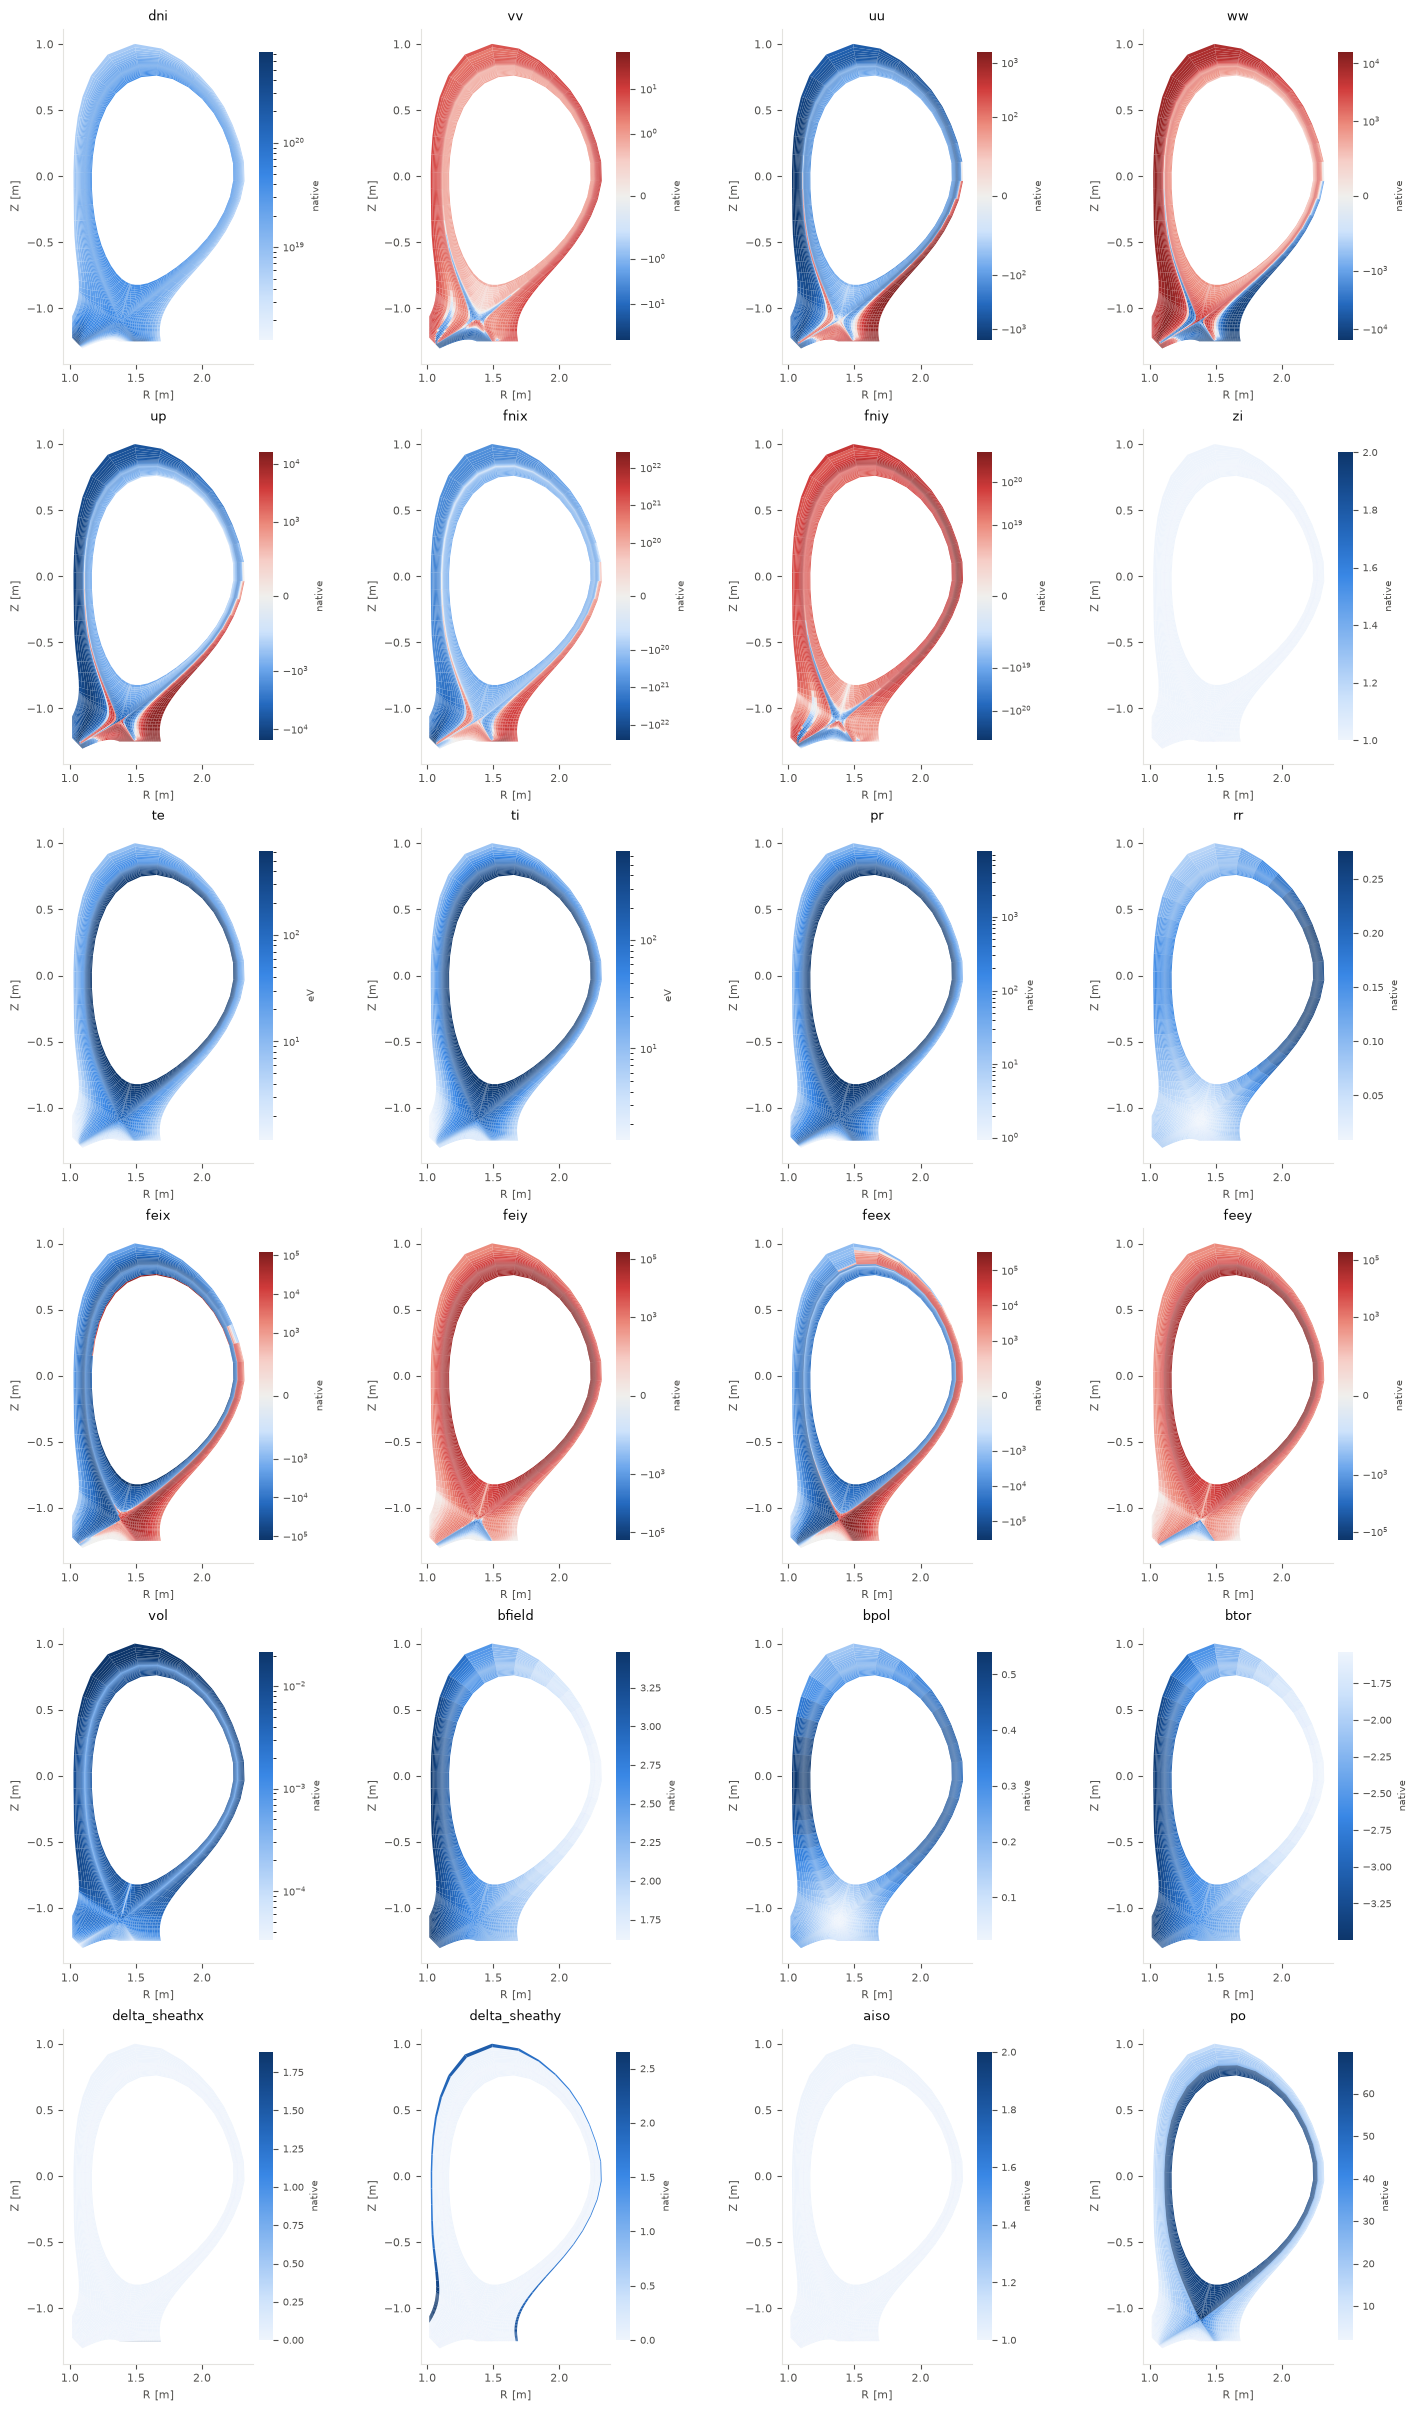

In [5]:
input_fields = cell_field_names(used, "braeir_")
zero_inputs = [name for name in cell_field_names(used, "braeir_", skip_zero=False) if name not in input_fields]
print(f"{len(input_fields)} non-zero input fields plotted; all-zero in this case: {', '.join(n.split('_', 1)[1] for n in zero_inputs)}")
fig, _ = plot_cell_gallery(used, mesh, input_fields, ncols=4)
plt.show()

## Returned plasma sources (EIRBRA): totals

Particle, parallel-momentum, electron-energy and ion-energy sources summed over strata with the B2.5 weighting. These four are the quantities B2 ultimately needs; everything in the next two sections is their decomposition.

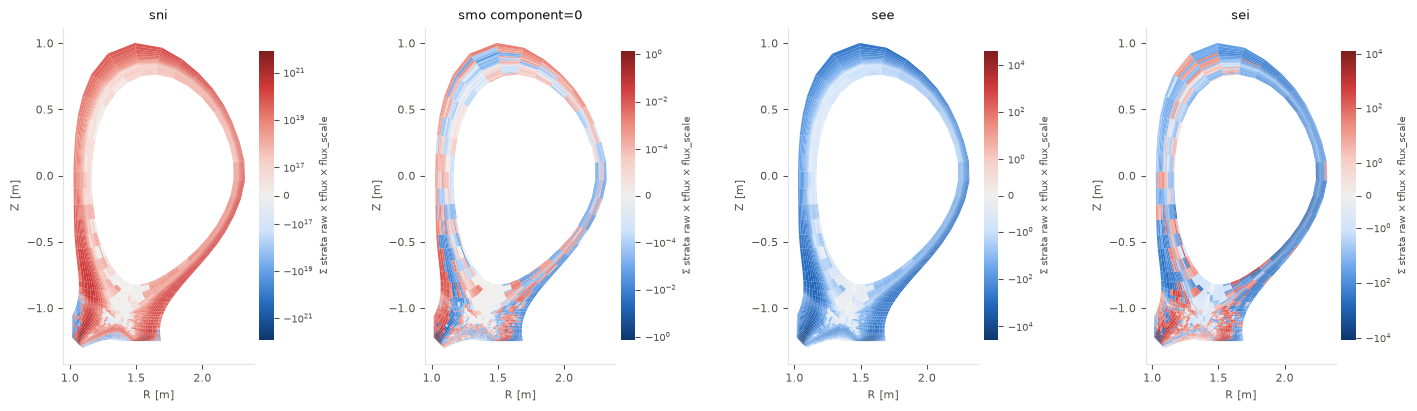

In [6]:
fig, _ = plot_cell_gallery(used, mesh, [
    "eirbra_sni", ("eirbra_smo", {"component": 0}), "eirbra_see", "eirbra_sei",
], ncols=4)
plt.show()

### One panel per stratum (raw estimators)

The stratum label is the B2 source type (`W`/`E` targets, `S` sides, `N` wall, `C` core/puff, `V` volume recombination). The network has to produce every active stratum separately because B2.5 scales each by its own `tflux`.

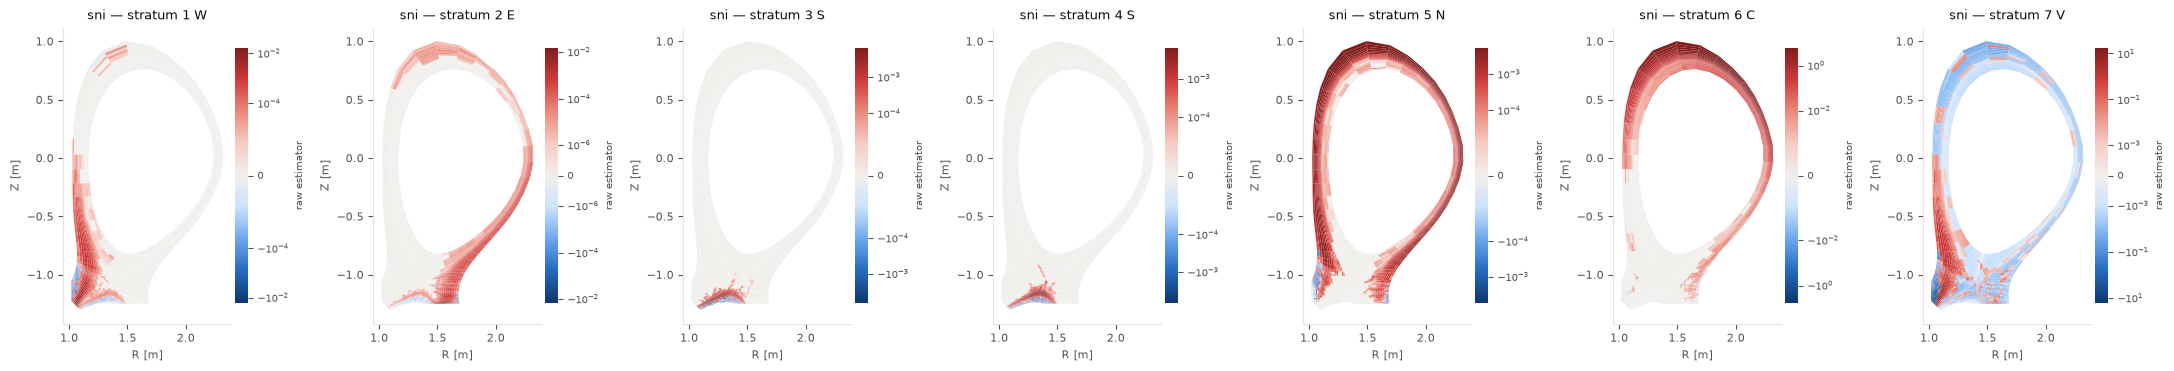

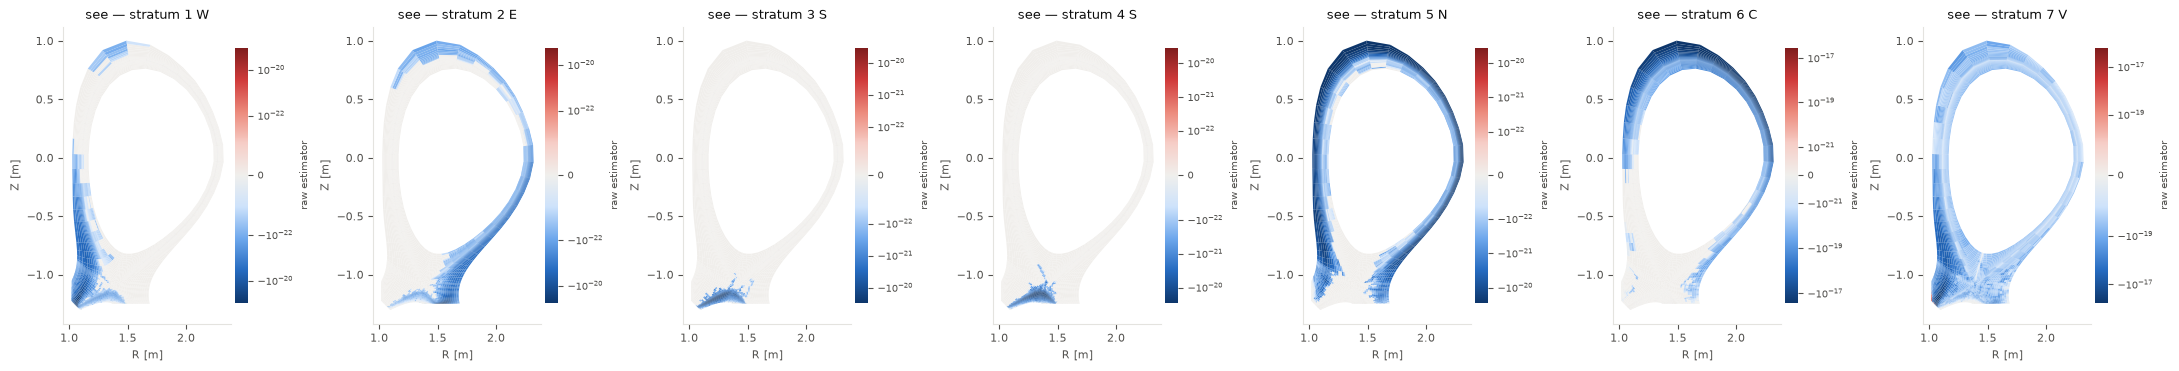

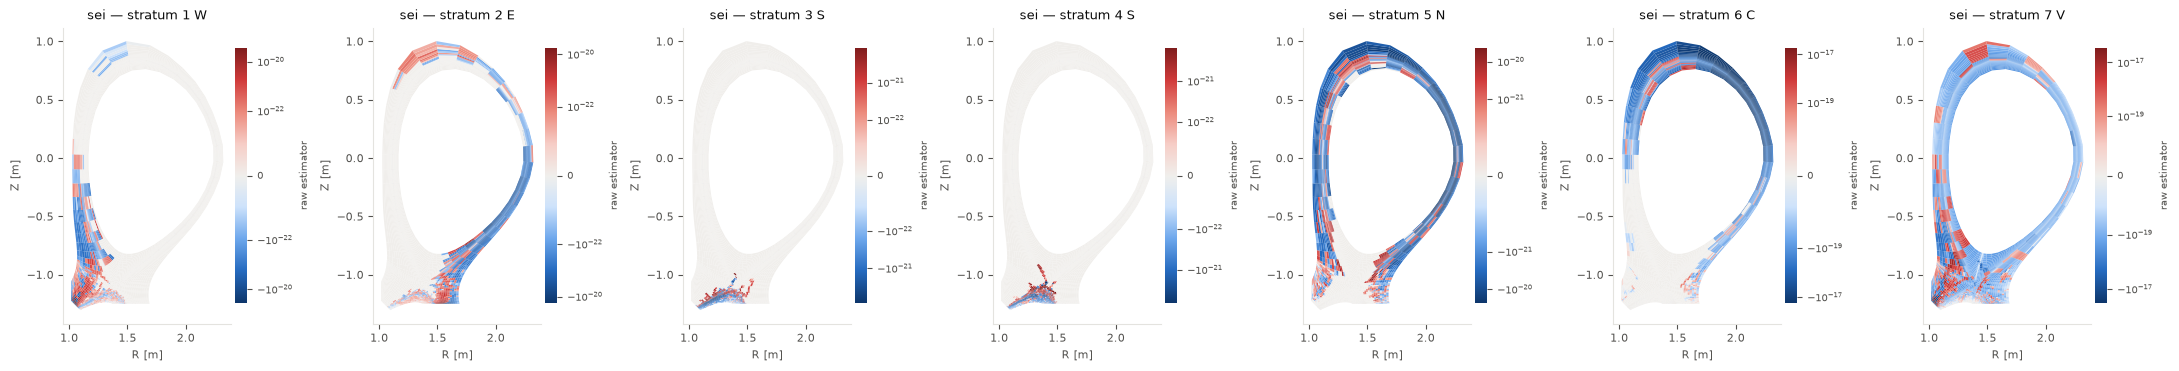

In [7]:
for name in ("eirbra_sni", "eirbra_see", "eirbra_sei"):
    fig, _ = plot_strata(used, mesh, name)
    plt.show()

### Reaction-channel decomposition

Every non-zero EIRBRA channel, summed over strata. The four totals above are exact sums of their channels (`sni = papl + pmpl + pipl + pppl`, and likewise for momentum and energy), so a model can predict either the channels or the totals, not both independently.

25 channel fields, 2 additional momentum slots


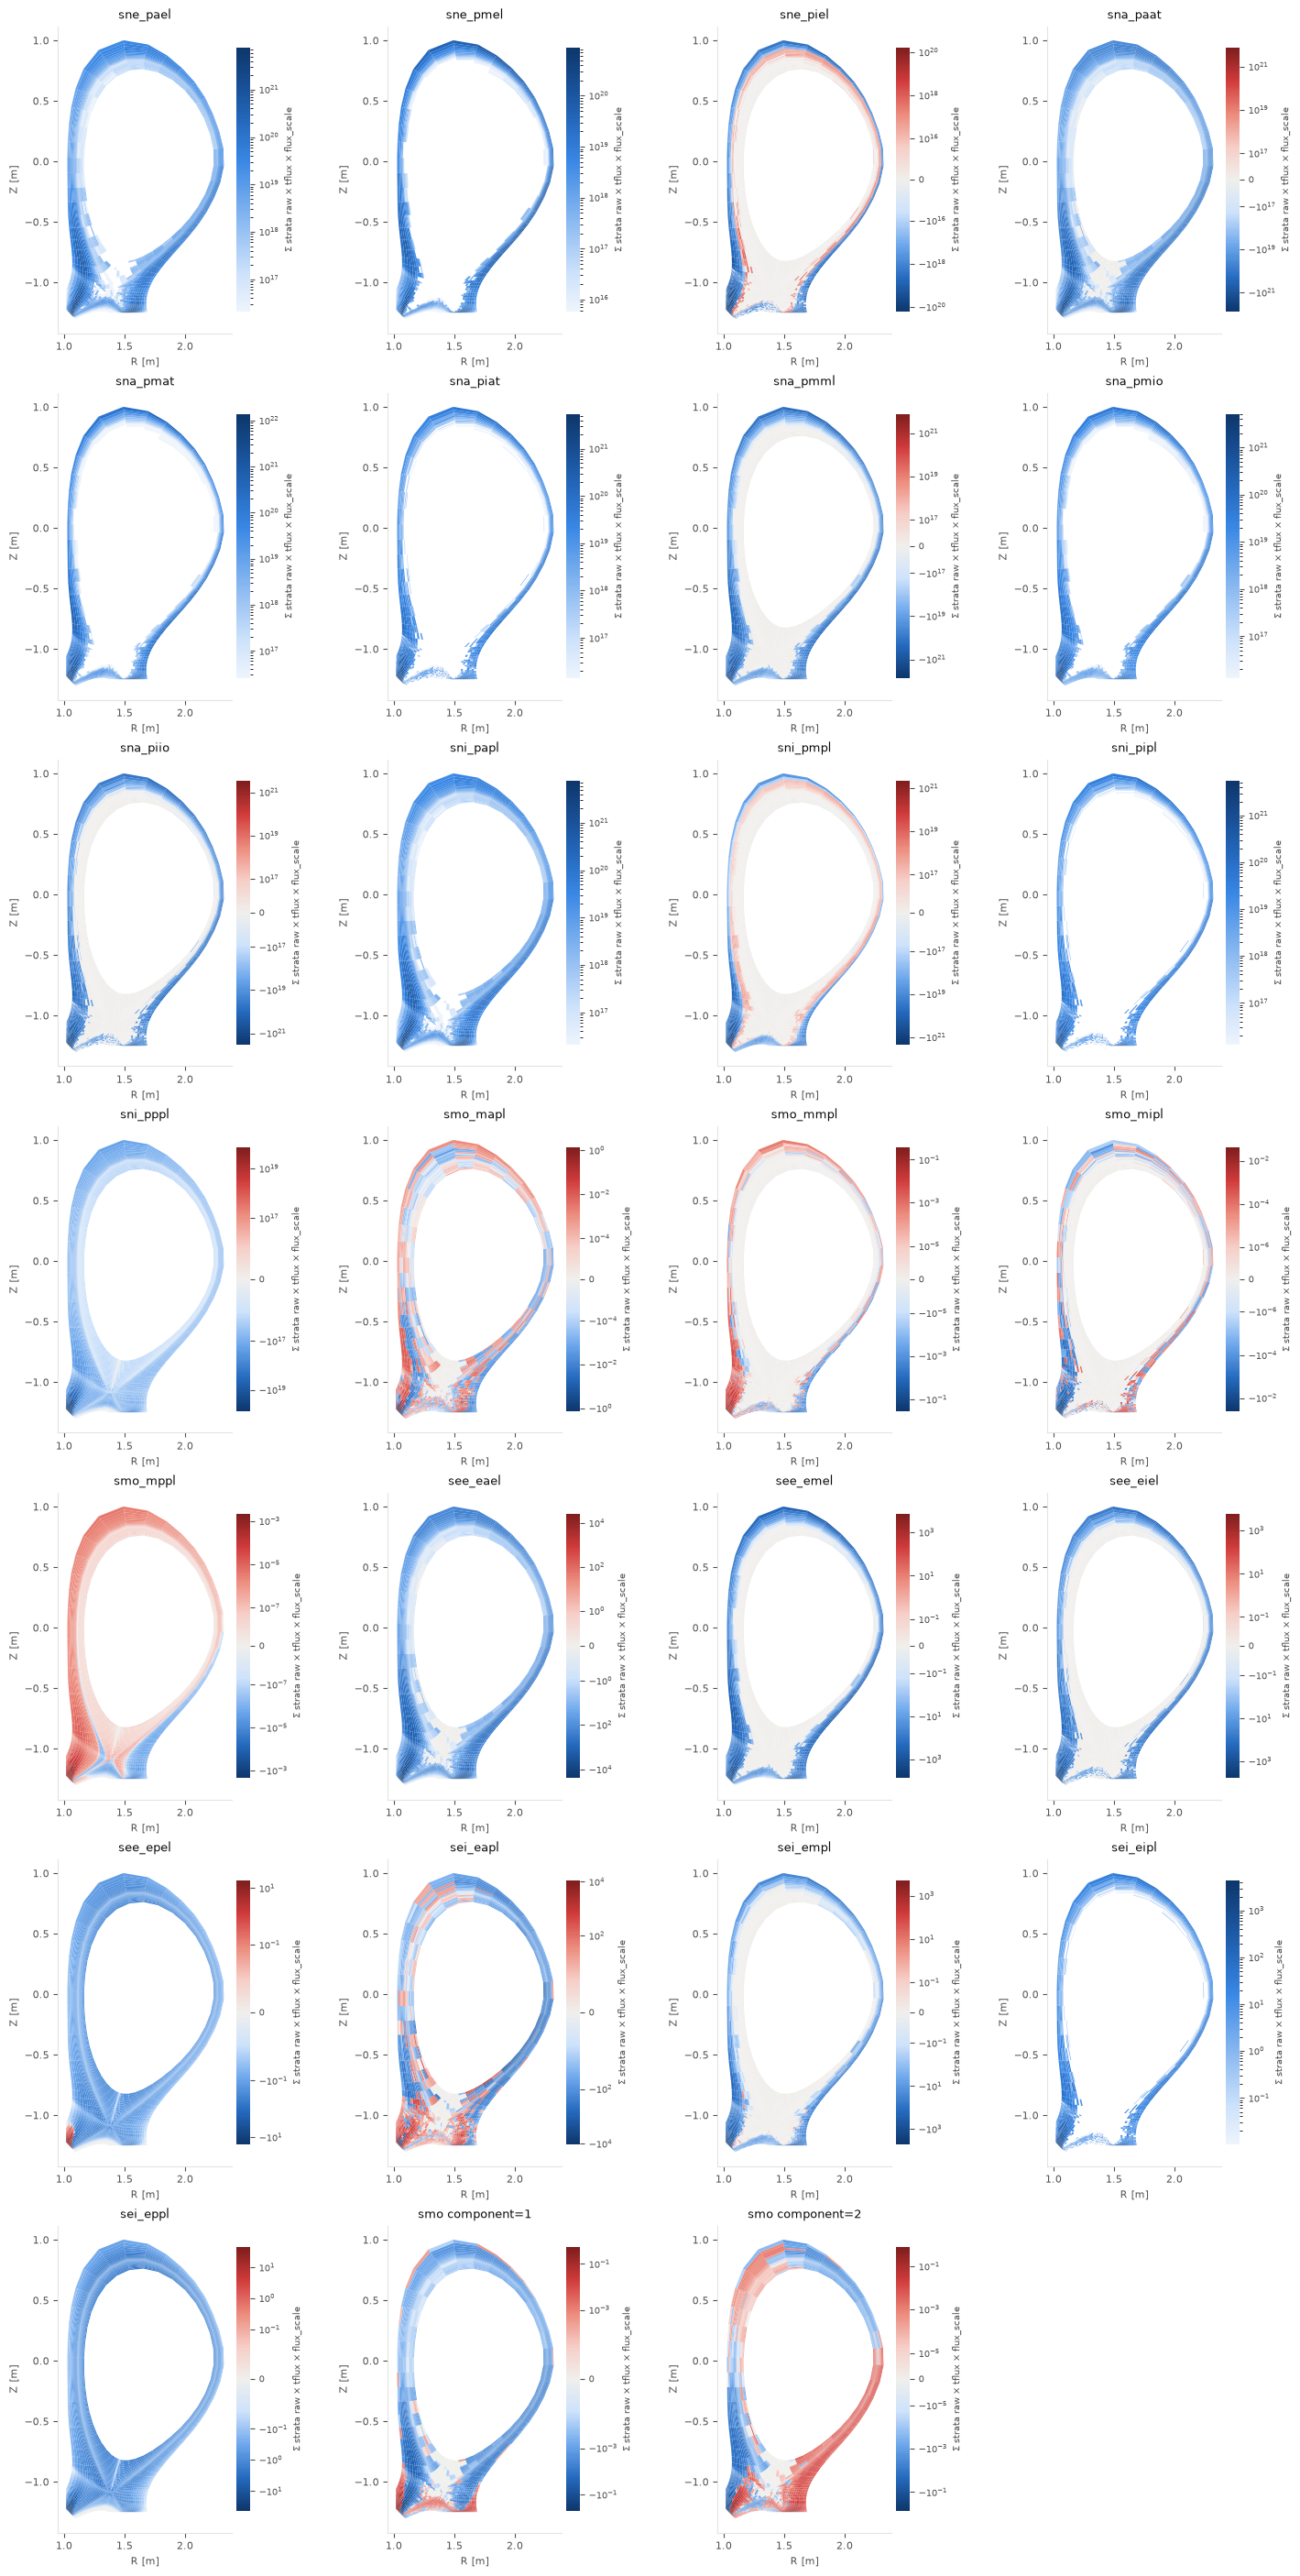

In [8]:
totals = {"eirbra_sni", "eirbra_smo", "eirbra_see", "eirbra_sei"}
channels = [name for name in cell_field_names(used, "eirbra_") if name not in totals]
other_momentum = [("eirbra_smo", {"component": c}) for c in (1, 2) if np.any(used["eirbra_smo"].values[:, c])]
print(f"{len(channels)} channel fields, {len(other_momentum)} additional momentum slots")
fig, _ = plot_cell_gallery(used, mesh, channels + other_momentum, ncols=4)
plt.show()

## Returned neutral state on the B2 mesh (WNEUTRALS)

Densities, temperatures, flux densities, emission and radiation of atoms, molecules and test ions. Stratum-resolved radiation arrays show the EIRENE total (slot 0).

23 non-zero neutral cell fields


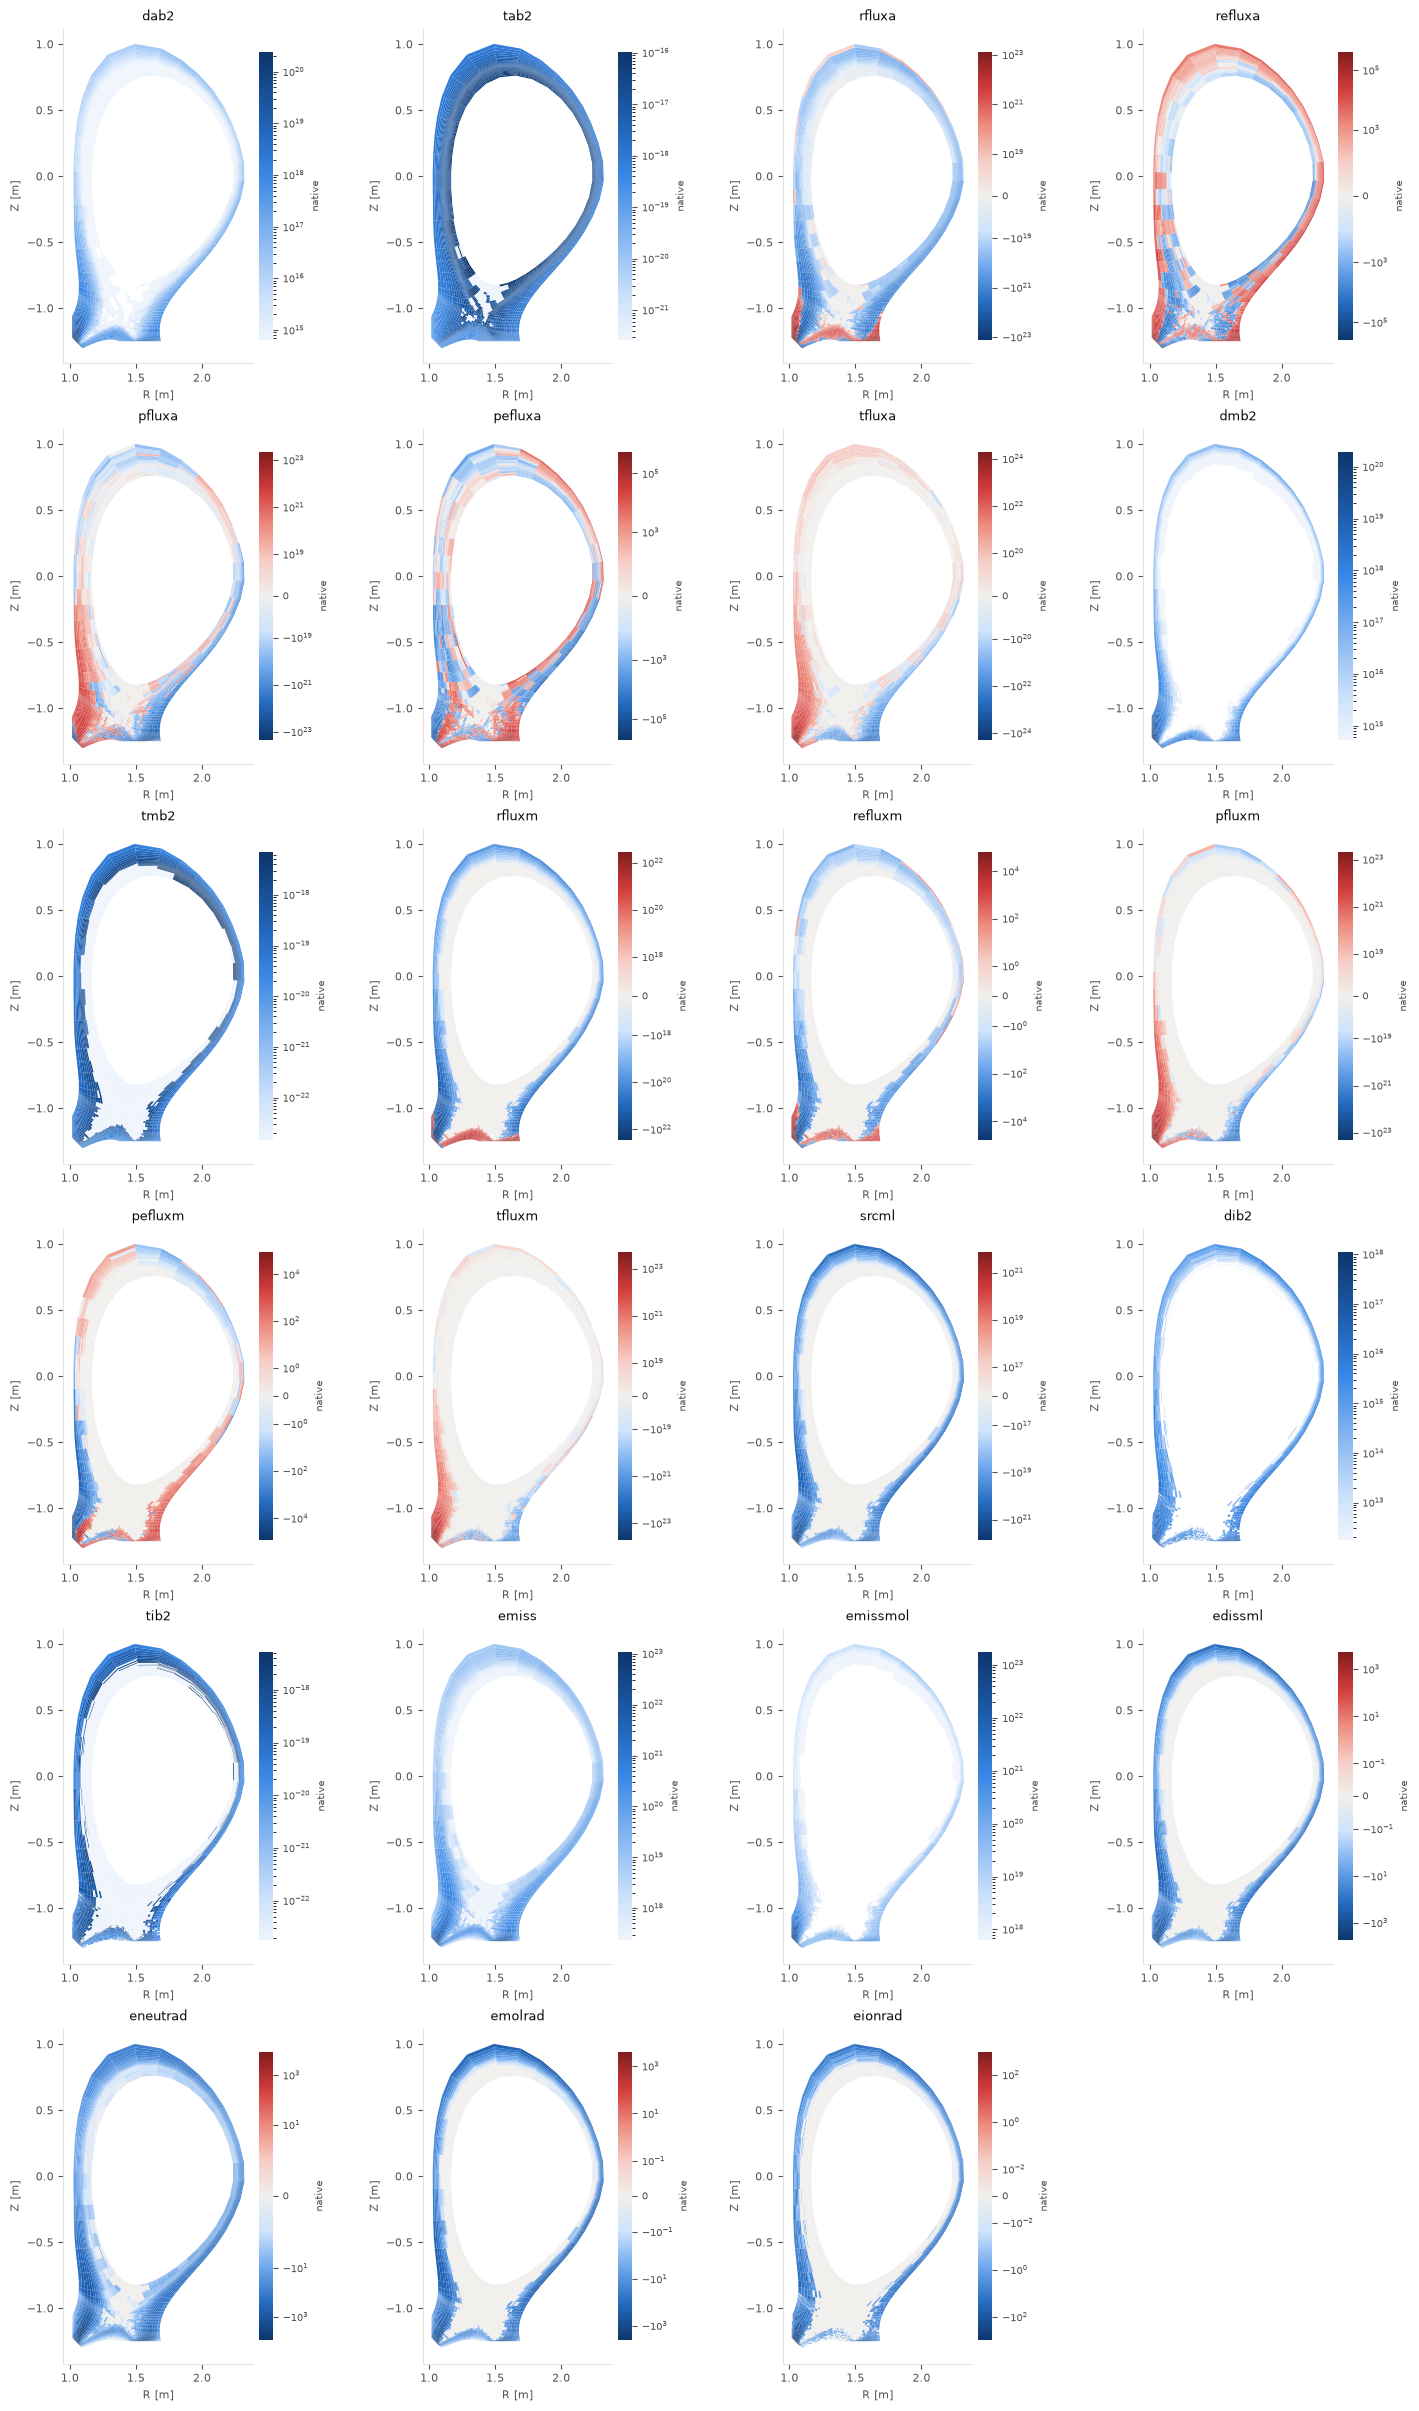

In [9]:
neutral_fields = cell_field_names(used, "wneutrals_")
print(f"{len(neutral_fields)} non-zero neutral cell fields")
fig, _ = plot_cell_gallery(used, mesh, neutral_fields, ncols=4)
plt.show()

## Triangle-grid estimators (CESTIM)

Particle, energy and velocity-moment estimators on EIRENE's own triangular mesh, which extends beyond the B2 grid to the vessel wall.

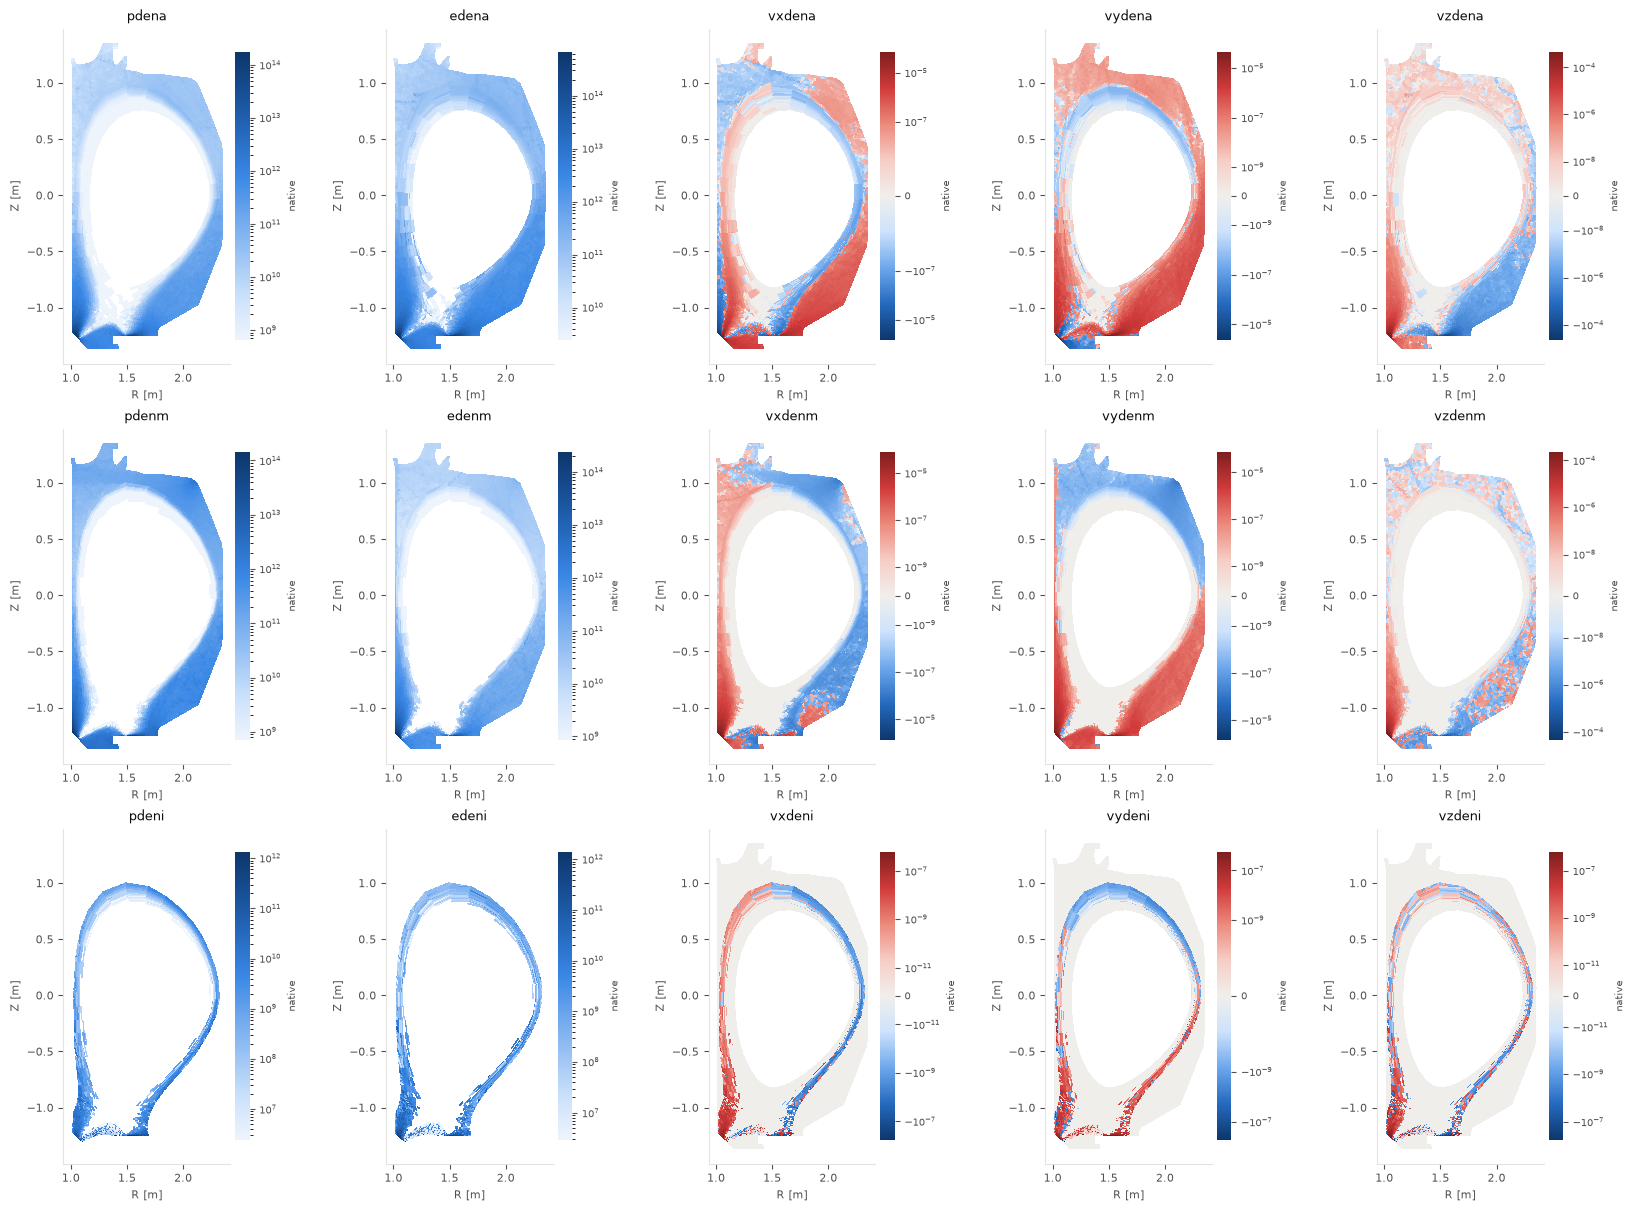

In [10]:
triangle_fields = [name for name in used.variables if name.startswith("cestim_")]
if triangles is None:
    print("fort.33 / fort.34 not found next to the event files: triangle plots skipped.")
else:
    fig, _ = plot_triangles(used, triangles, triangle_fields, ncols=5, panel=(3.3, 4.0))
    plt.show()

## Wall and resolved-surface tallies

One value per EIRENE surface (stratum total, first species), for both calls. A logarithmic axis is used where a tally spans more than two decades.

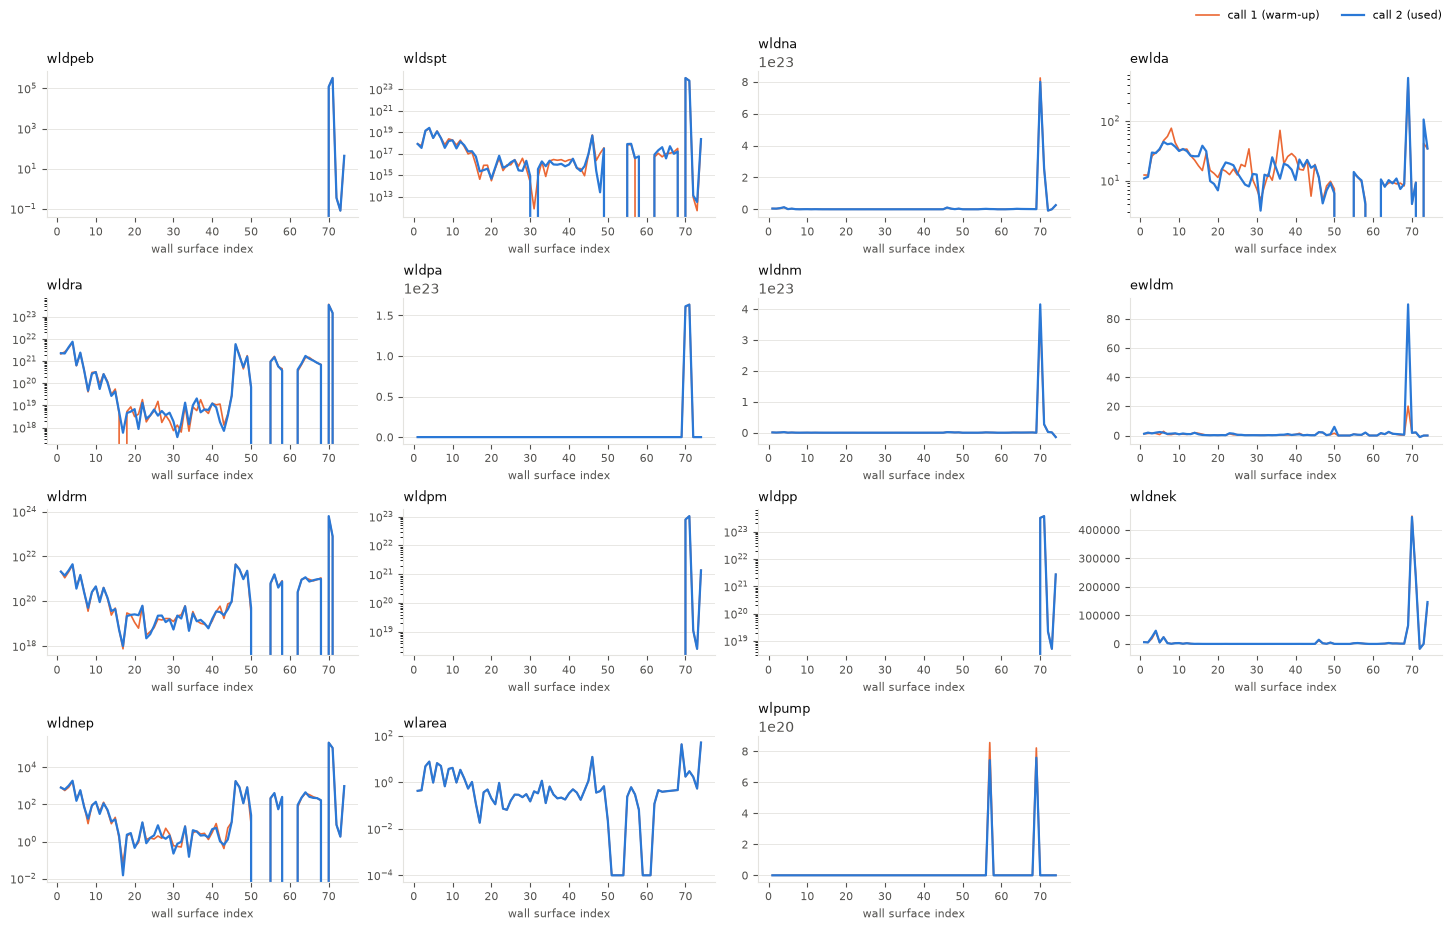

In [11]:
wall_fields = surface_names(used, "wall surface")
fig, _ = plot_surfaces(used, wall_fields, warmup=warmup, ncols=4, xlabel="wall surface index")
plt.show()

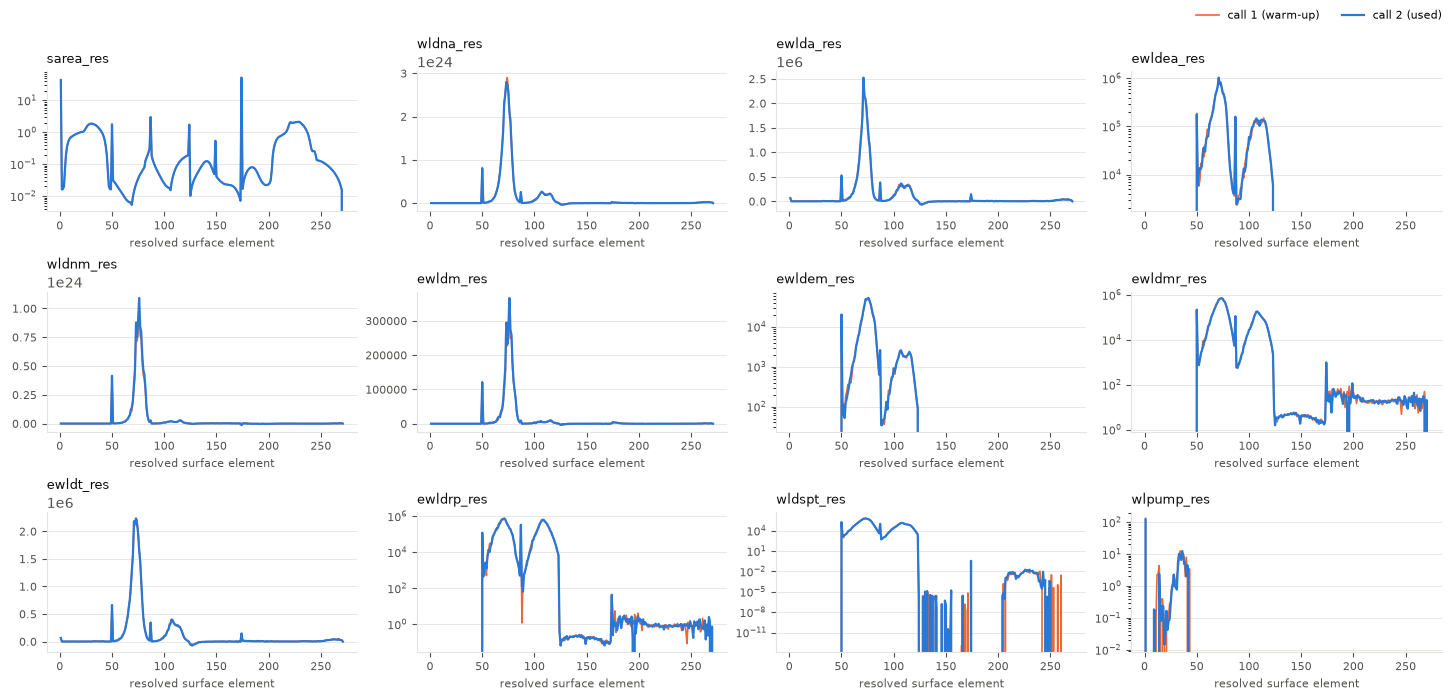

In [12]:
resolved_fields = surface_names(used, "resolved surface")
fig, _ = plot_surfaces(used, resolved_fields, warmup=warmup, ncols=4, xlabel="resolved surface element")
plt.show()

## Call 1 against call 2: how noisy is one EIRENE call?

Both calls saw identical inputs, so their difference is Monte Carlo noise unless a quantity behaves differently on the very first call. The right-hand column is the relative difference in every cell where call 2 is non-zero; the colour scale saturates at ±100 %.

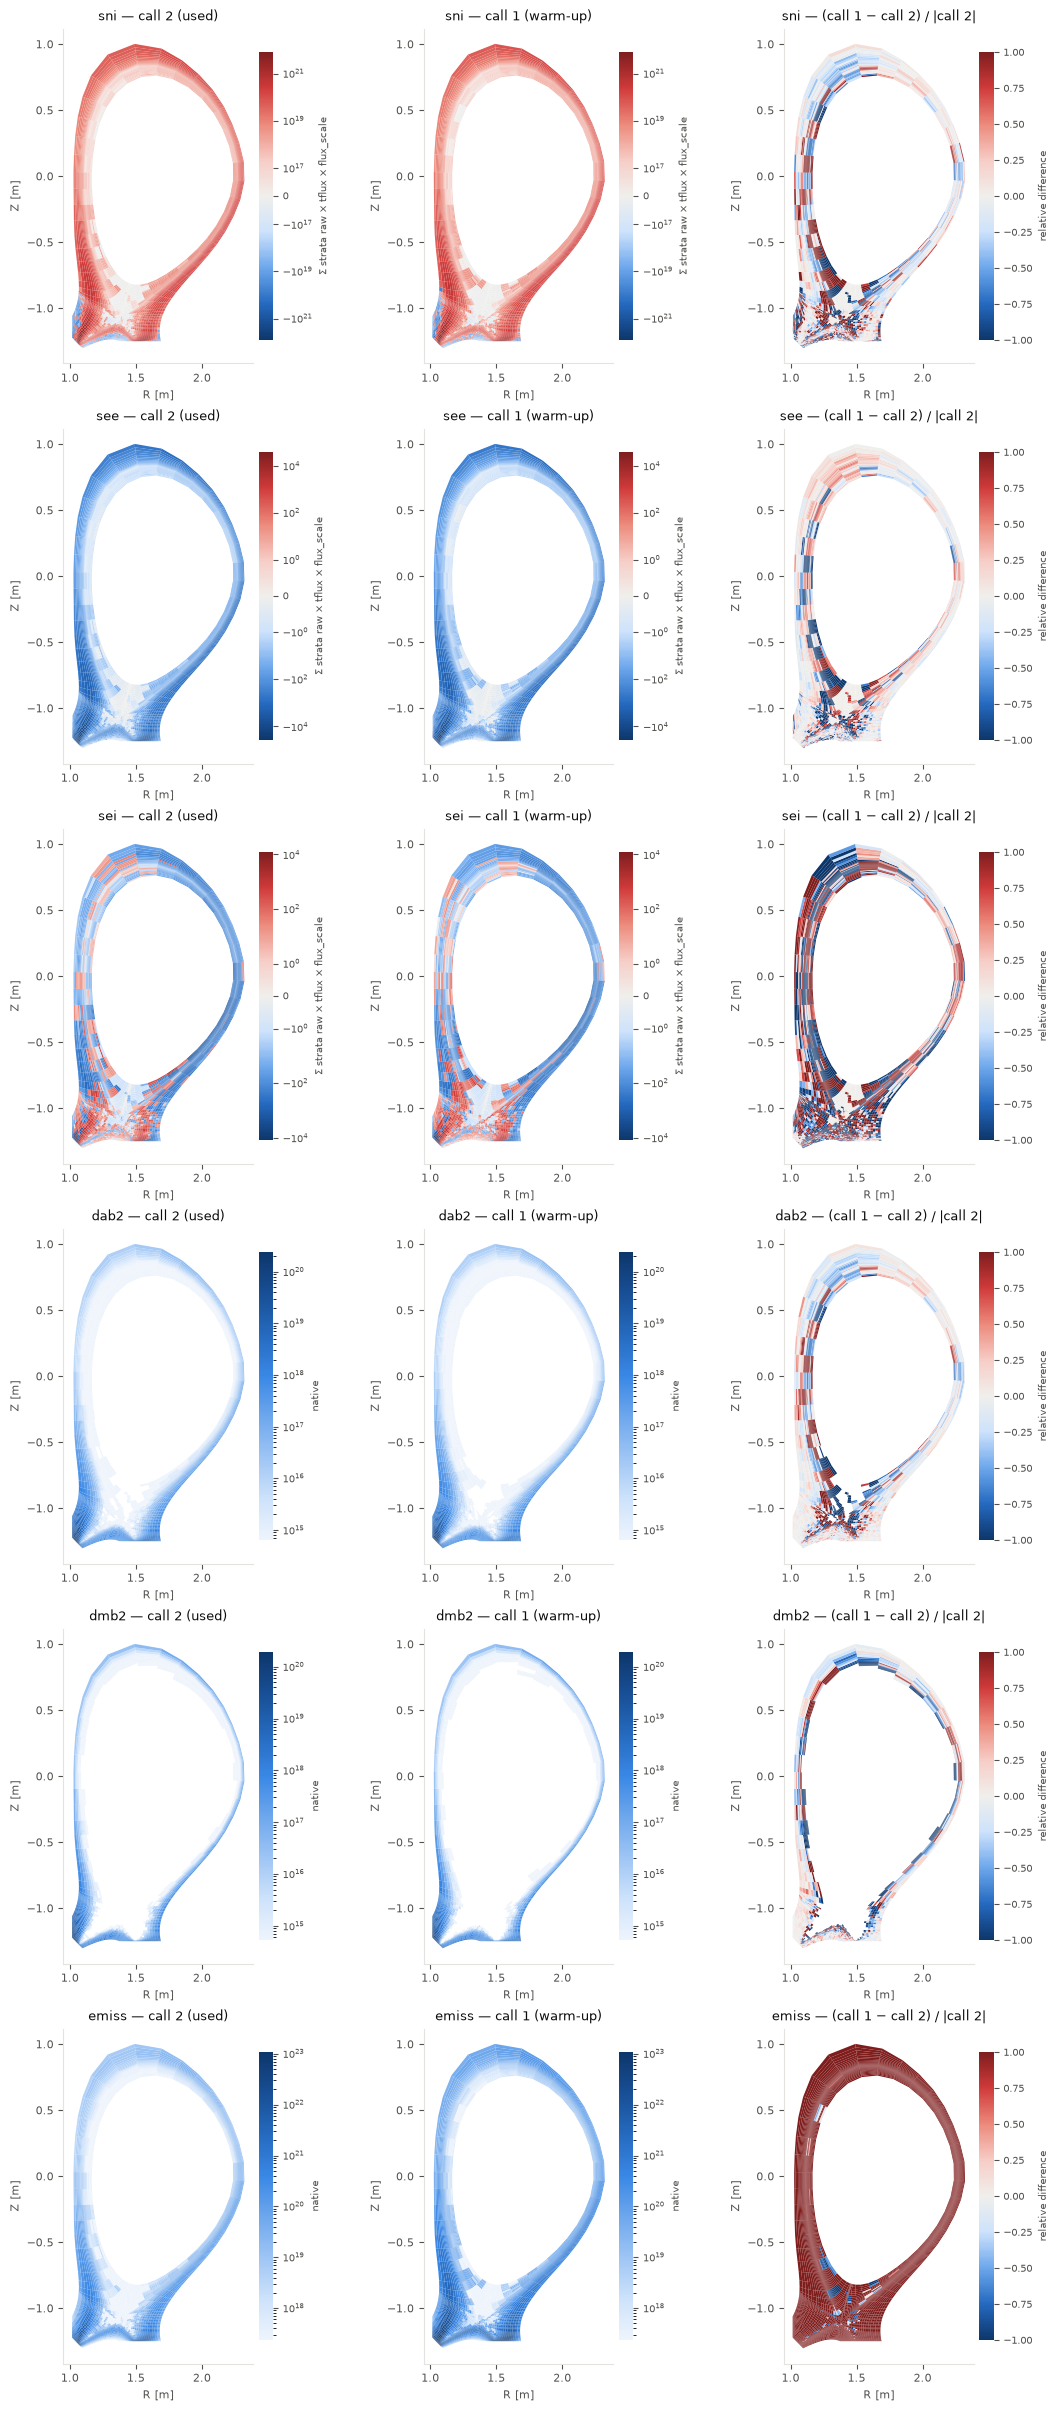

In [13]:
fig, _ = plot_call_comparison(used, warmup, mesh, [
    "eirbra_sni", "eirbra_see", "eirbra_sei", "wneutrals_dab2", "wneutrals_dmb2", "wneutrals_emiss",
])
plt.show()

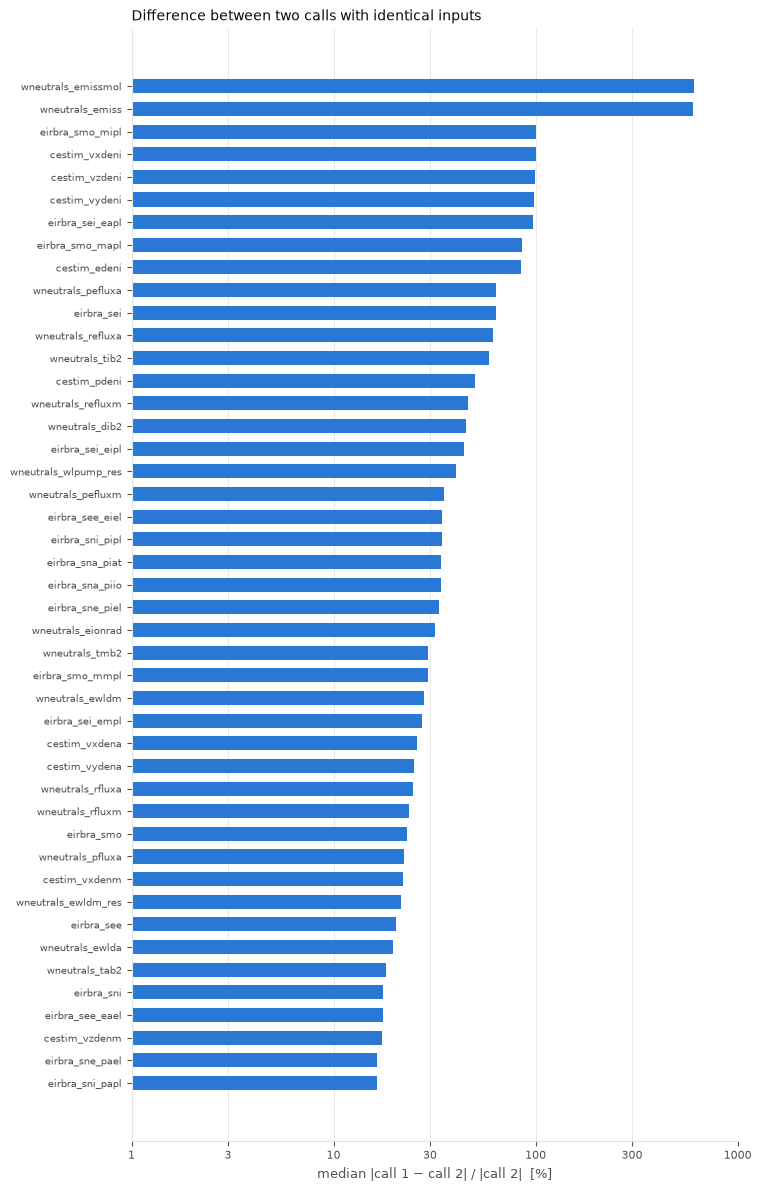

variable,sum(call 1) / sum(call 2)
wneutrals_emiss,7.035
wneutrals_emissmol,7.129
wneutrals_dab2,1.012
wneutrals_dmb2,1.017
wneutrals_srcml,1.010


In [14]:
fig, _ = plot_noise_ranking(table, top=45)
plt.show()

ratio_rows = []
for name in ("wneutrals_emiss", "wneutrals_emissmol", "wneutrals_dab2", "wneutrals_dmb2", "wneutrals_srcml"):
    first, second = warmup[name].values, used[name].values
    ratio_rows.append({"variable": name, "sum(call 1) / sum(call 2)": float(first.sum() / second.sum())})
display(pd.DataFrame(ratio_rows).style.hide(axis="index").format({"sum(call 1) / sum(call 2)": "{:.3f}"}))

The emission fields `emiss` and `emissmol` are not ordinary noise: call 1 is larger than call 2 by a near-uniform factor close to the number of strata, while densities and source rates agree to about 1 % in the integral. That is a first-call effect inside EIRENE, and one more reason to train on call 2 only.

## Candidate training set for this pure-D case

In [15]:
returned = table[table["group"] != "input"]
for role in ("stochastic return", "deterministic return", "configuration", "zero in this case"):
    subset = returned[returned["role"] == role]
    print(f"\n{role}: {len(subset)} variables, {int(subset['values'].sum()):,} values")
    for layout, group in subset.groupby("layout"):
        print(f"  {layout:17s} {len(group):3d}  " + ", ".join(name.split('_', 1)[1] for name in group["variable"]))


stochastic return: 100 variables, 1,303,846 values
  B2 cell field      48  sni, smo, see, sei, sne_pael, sne_pmel, sne_piel, sna_paat, sna_pmat, sna_piat, sna_pmml, sna_pmio, sna_piio, sni_papl, sni_pmpl, sni_pipl, smo_mapl, smo_mmpl, smo_mipl, see_eael, see_emel, see_eiel, sei_eapl, sei_empl, sei_eipl, dab2, tab2, rfluxa, refluxa, pfluxa, pefluxa, tfluxa, dmb2, tmb2, rfluxm, refluxm, pfluxm, pefluxm, tfluxm, srcml, dib2, tib2, emiss, emissmol, edissml, eneutrad, emolrad, eionrad
  other               1  eirpump
  per stratum        12  pdena_int, pdena_int_b2, edena_int, edena_int_b2, pdenm_int, pdenm_int_b2, edenm_int, edenm_int_b2, pdeni_int, pdeni_int_b2, edeni_int, edeni_int_b2
  resolved surface   11  wldna_res, ewlda_res, ewldea_res, wldnm_res, ewldm_res, ewldem_res, ewldmr_res, ewldt_res, ewldrp_res, wldspt_res, wlpump_res
  triangle field     15  pdena, edena, vxdena, vydena, vzdena, pdenm, edenm, vxdenm, vydenm, vzdenm, pdeni, edeni, vxdeni, vydeni, vzdeni
  wall surface   

## Reading this for the surrogate

- **Train on call 2.** It is what B2 uses, and at least the emission fields differ systematically on call 1.
- **Network outputs** are the `stochastic return` variables. Most of the stored values are cell fields on the B2 mesh and the triangle estimators; the wall and resolved-surface tallies are small vectors.
- **Deterministic returns** (the volume-recombination channels `pppl`, `mppl`, `epel`, `eppl` and the stratum scalars) carry no Monte Carlo noise but do depend on the plasma, so they need a model or the closed-form rate, not a constant.
- **Configuration** arrays can be read once and replayed by the aggregator.
- **Zero arrays** are zero because this case is pure deuterium with wall sputtering and impurity injection off. They stay in the contract so that carbon and neon cases only add outputs rather than change the interface.
- **One event cannot show what is constant across plasma states.** Both calls here share one plasma. Repeating this inventory over a handful of different cases is the step that separates true constants from plasma-dependent outputs.